# Libraries
---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mutual_info_score
from scipy.spatial.distance import pdist
from scipy.stats import linregress
from sklearn.neighbors import NearestNeighbors

from extract.e_d import extract_data as ed

from figures.v_d import f_data as fd
from figures.v_d import plot_mutual_information as vfd
from figures.v_d import plot_correlation_integral as pci
from figures.v_d import plot_correlation_dimension as pcd
from figures.v_d import plot_lyapunov_fit as plf

from Average_Mutual_Information import calculate_mutual_information as cmi
from Average_Mutual_Information import calculate_mutual_information as fflm

from Q2.ccdm import create_embedding as ce
from Q2.ccdm import calculate_correlation_integral as cci
from Q2.ccdm import estimate_correlation_dimension as ecd

from Q3.CmLe import find_nearest_neighbors as fnn

from Q4.CalculateMLe import calculate_average_log_divergence as calg

# Main
---

### i) 1. Φόρτωση δεδομένων

In [2]:
x = ed()

print(x)
print("Πλήθος τιμών:", len(x))

[-0.1597695  0.7581872  0.3502534 ...  0.8164985  0.2659069  1.218522 ]
Πλήθος τιμών: 5000


### i) Παρουσίαση της χρονοσειράς 

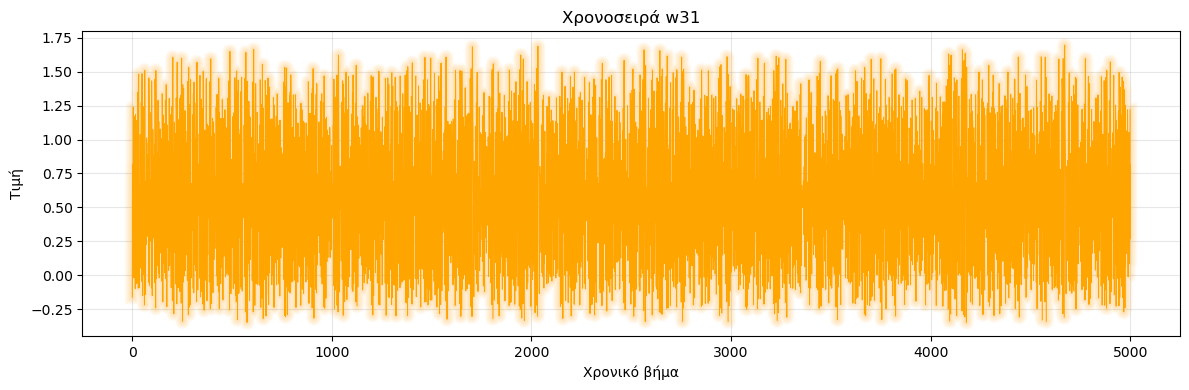

In [3]:
fd(x)

### i) Υπολογισμός του time delay με Average Mutual Information

In [4]:
x_analysis = x[:-1]

In [5]:
max_lag = 100

mi_values  = cmi.calculate_mutual_information(x_analysis, max_lag, 32) 

In [6]:
lags = np.arange(1, max_lag + 1)

for lag, mi in zip(lags[:10], mi_values[:10]):
    print(f"lag = {lag:2d} | Mutual Information = {mi:.6f}")

lag =  1 | Mutual Information = 0.756596
lag =  2 | Mutual Information = 0.568216
lag =  3 | Mutual Information = 0.413509
lag =  4 | Mutual Information = 0.320969
lag =  5 | Mutual Information = 0.252255
lag =  6 | Mutual Information = 0.192157
lag =  7 | Mutual Information = 0.164865
lag =  8 | Mutual Information = 0.149123
lag =  9 | Mutual Information = 0.135725
lag = 10 | Mutual Information = 0.118493


### i)

In [7]:
tau, minimum_index = fflm.find_first_local_minimum(mi_values, lags)

Selected time delay τ = 12
Mutual Information at the selected τ = 0.10162091178488714


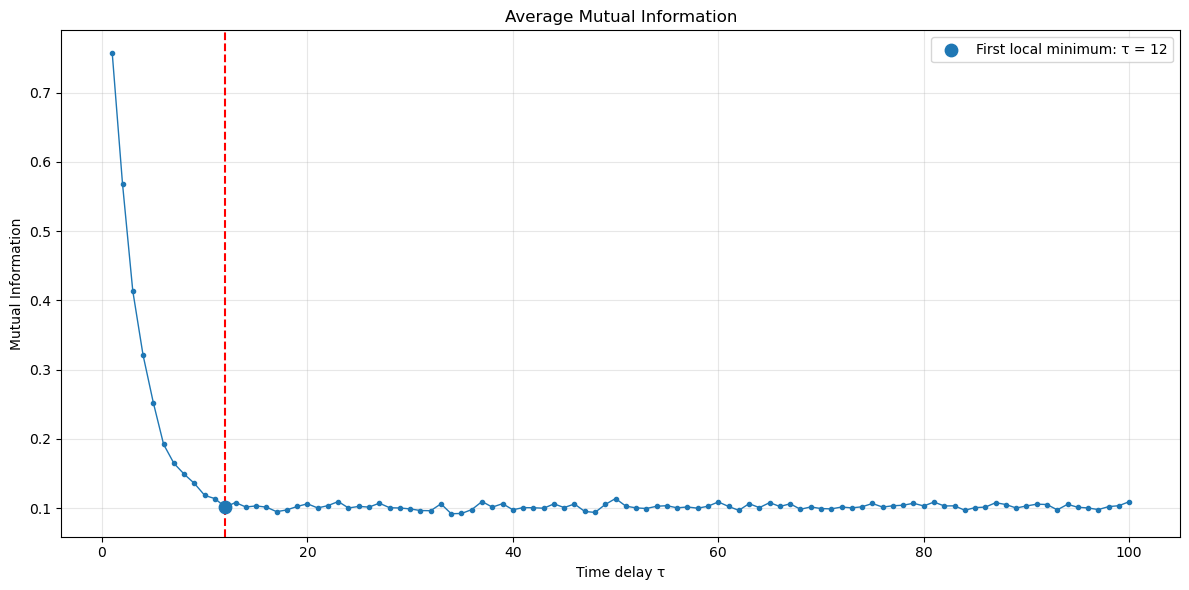

In [8]:
vfd(lags, mi_values, tau, minimum_index)

---
### ii)

In [9]:
embedded_m3 = ce(series=x_analysis, embedding_dim=3, tau=12)

In [10]:
distances = pdist(embedded_m3)

In [11]:
minimum_radius = np.percentile(distances, 1)
maximum_radius = np.percentile(distances, 30)

radii = np.logspace(np.log10(minimum_radius), np.log10(maximum_radius), 40)

In [12]:
correlation_integrals = cci(embedded=embedded_m3, radii=radii)

for radius, correlation in zip(radii[:10], correlation_integrals[:10]):
    print(f"r = {radius:.6f} | C(r) = {correlation:.6f}")

r = 0.245165 | C(r) = 0.010000
r = 0.253214 | C(r) = 0.010984
r = 0.261527 | C(r) = 0.012058
r = 0.270113 | C(r) = 0.013245
r = 0.278982 | C(r) = 0.014549
r = 0.288141 | C(r) = 0.015974
r = 0.297601 | C(r) = 0.017542
r = 0.307372 | C(r) = 0.019229
r = 0.317463 | C(r) = 0.021085
r = 0.327886 | C(r) = 0.023133


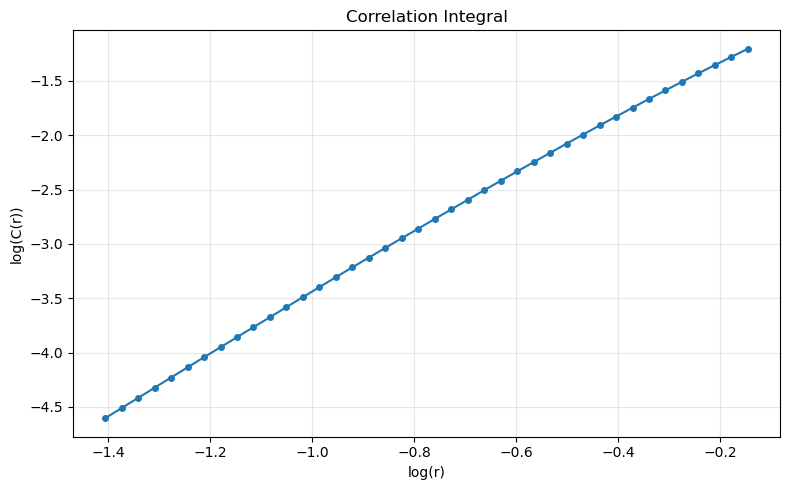

In [13]:
pci(radii, correlation_integrals)

In [14]:
dimension, r_squared = ecd(radii, correlation_integrals)

print("Estimated correlation dimension:", dimension)
print("R² of linear fit:", r_squared)

Estimated correlation dimension: 2.767818602943268
R² of linear fit: 0.999623759335575


In [15]:
embedding_dimensions = range(1, 11)

estimated_dimensions = []

for m in embedding_dimensions:

    embedded = ce(series=x_analysis, embedding_dim=m, tau=tau)

    distances = pdist(embedded)

    minimum_radius = np.percentile(distances, 1)
    maximum_radius = np.percentile(distances, 30)

    radii = np.logspace(np.log10(minimum_radius), np.log10(maximum_radius), 40)

    correlation_integrals = cci(embedded, radii)

    dimension, r_squared = ecd(radii, correlation_integrals)

    estimated_dimensions.append(dimension)

    print(f"m = {m:2d} | " f"Estimated D2 = {dimension:.4f} | " f"R² = {r_squared:.4f}")

m =  1 | Estimated D2 = 0.9874 | R² = 1.0000
m =  2 | Estimated D2 = 1.9271 | R² = 0.9999
m =  3 | Estimated D2 = 2.7678 | R² = 0.9996
m =  4 | Estimated D2 = 3.5202 | R² = 0.9994
m =  5 | Estimated D2 = 4.2134 | R² = 0.9991
m =  6 | Estimated D2 = 4.8563 | R² = 0.9989
m =  7 | Estimated D2 = 5.4361 | R² = 0.9987
m =  8 | Estimated D2 = 6.0252 | R² = 0.9985
m =  9 | Estimated D2 = 6.5654 | R² = 0.9984
m = 10 | Estimated D2 = 7.0816 | R² = 0.9982


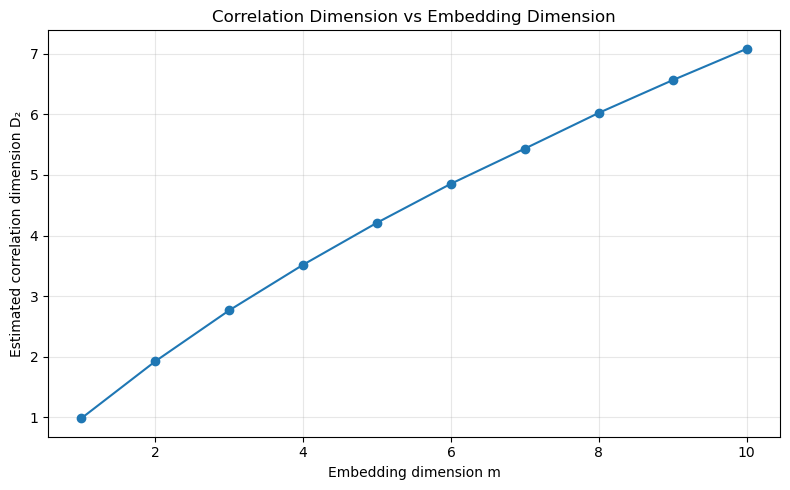

In [16]:
pcd(embedding_dimensions, estimated_dimensions)

---
### iii)

In [17]:
embedding_dim = 4

embedded = ce(series=x_analysis, embedding_dim=embedding_dim, tau=tau)

In [18]:
theiler_window = tau

In [19]:
nearest_neighbors = fnn(embedded=embedded, theiler_window=theiler_window)

In [20]:
print(nearest_neighbors.shape)
print(nearest_neighbors[:10])

(4963,)
[ 798 4406 1525 2375 3077  957 2948 2326  409 3999]


In [21]:
max_steps = 50

average_log_divergence = calg(embedded=embedded, nearest_neighbors=nearest_neighbors, max_steps=max_steps)

steps = np.arange(len(average_log_divergence))

print(average_log_divergence[:10])

[-2.03610321 -0.05885596  0.06130572  0.12394385  0.16163649  0.16345808
  0.18228477  0.18073792  0.15418219  0.14726775]


In [22]:
#fit_start = 1
#fit_end = 6

fit_start = 2
fit_end = 7

result = linregress(steps[fit_start:fit_end], average_log_divergence[fit_start:fit_end])

lyapunov_exponent = result.slope
intercept = result.intercept
r_squared = result.rvalue ** 2

print("Maximal Lyapunov exponent =", lyapunov_exponent)
print("R² =", r_squared)

Maximal Lyapunov exponent = 0.028147232697171065
R² = 0.8568617354214314


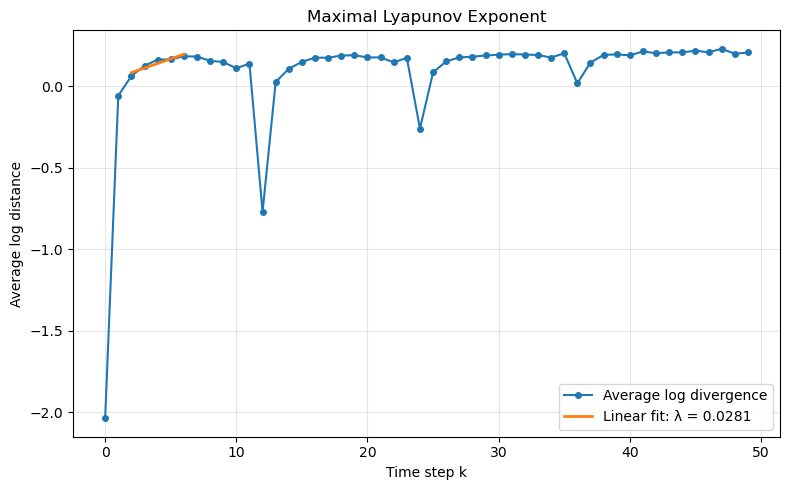

In [23]:
plf(steps=steps, average_log_divergence=average_log_divergence, fit_start=2, fit_end=7, lyapunov_exponent=lyapunov_exponent, intercept=intercept)

---
### iv)

In [24]:
def create_forecasting_dataset(series, embedding_dim, tau):
    series = np.asarray(series, dtype=float)

    states = []
    targets = []

    first_time = (embedding_dim - 1) * tau

    for t in range(first_time, len(series) - 1):

        state = [
            series[t - lag * tau]
            for lag in range(embedding_dim - 1, -1, -1)
        ]

        states.append(state)

        # Η αμέσως επόμενη τιμή είναι ο στόχος
        targets.append(series[t + 1])

    return np.asarray(states), np.asarray(targets)

In [25]:
def create_last_state(series, embedding_dim, tau):
    series = np.asarray(series, dtype=float)

    last_state = [
        series[-1 - lag * tau]
        for lag in range(embedding_dim - 1, -1, -1)
    ]

    return np.asarray(last_state)

In [26]:
tau = 12
embedding_dim = 4
number_of_neighbors = 5
theiler_window = tau

x_analysis = x[:-1]
actual_last_value = x[-1]

X_train, y_train = create_forecasting_dataset(series=x_analysis, embedding_dim=embedding_dim, tau=tau)
last_state = create_last_state(series=x_analysis, embedding_dim=embedding_dim, tau=tau)

X_valid = X_train[:-theiler_window]
y_valid = y_train[:-theiler_window]

neighbor_model = NearestNeighbors(n_neighbors=number_of_neighbors, metric="euclidean")

neighbor_model.fit(X_valid)

distances, neighbor_indices = neighbor_model.kneighbors(last_state.reshape(1, -1))

distances = distances[0]
neighbor_indices = neighbor_indices[0]

neighbor_targets = y_valid[neighbor_indices]

weights = 1 / (distances + 1e-12)

predicted_last_value = np.sum(weights * neighbor_targets) / np.sum(weights)

relative_prediction_error = (abs(predicted_last_value - actual_last_value) / abs(actual_last_value) * 100)

In [27]:
print(f"Actual last value = {actual_last_value:.6f}")
print(f"Predicted last value = {predicted_last_value:.6f}")
print(f"Relative prediction error = {relative_prediction_error:.2f}%")

Actual last value = 1.218522
Predicted last value = 0.930282
Relative prediction error = 23.65%


---
##### The last value was removed from the time series and predicted with a nonlinear nearest-neighbor method.

The real last value was 1.218522, while the predicted value was 0.930282.

The relative prediction error was 23.65%.

This means that the prediction was not very accurate, but it was still close to the real value. The error may be caused by the complex and chaotic behavior of the time series.